# Exercise 2

This notebook answers Problem 2 of `exam.pdf` directly. The main study is a disorder-averaged random-state entanglement analysis on an open `4x4` TFIM lattice, while a smaller `2x2` benchmark is retained only to validate the SWAP / local-estimator implementation against the exact Renyi-2 entropy.

The report is organized exactly around Problem 2(a-e):

- `2/a` neural quantum state parameterization
- `2/b` architecture-agnostic Monte Carlo sampling
- `2/c` SWAP local estimator for Renyi-2
- `2/d` initialization-choice and disorder-averaged random-state study on `4x4`
- `2/e` architecture comparison with controlled within-family capacity sweeps on `4x4`


In [1]:
from notebook_bootstrap import bootstrap_notebook

bootstrap_notebook(enable_x64=True)

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from demos.exercise_report_helper import (
    add_report_figure_context,
    build_output_manifest,
    ensure_report_output_dir,
    save_report_figure,
    save_report_table,
)
from nqs.vmc_setup import build_model, build_variational_state
from nqs.workflows import (
    build_system,
    initialize_random_parameters,
    run_random_architecture_study,
    sampler_acceptance_diagnostics,
    sampler_mixing_diagnostics,
)

plt.style.use('seaborn-v0_8-whitegrid')


In [3]:
validation_config = {
    'lattice_shape': (2, 2),
    'pbc': False,
    'hamiltonian': 'tfim',
    'J': 1.0,
    'h': 2.5,
}

study_config = {
    'lattice_shape': (4, 4),
    'pbc': True,
    'hamiltonian': 'tfim',
    'J': 1.0,
    'h': 2.5,
}

validation_sampling_config = {
    'n_samples': 4096,
    'n_discard_per_chain': 256,
    'n_chains': 32,
    'entropy_n_independent_runs': 32,
}

initialization_sampling_config = {
    'n_samples': 2048,
    'n_discard_per_chain': 256,
    'n_chains': 32,
    'entropy_n_independent_runs': 24,
}

architecture_sampling_config = {
    'n_samples': 1024,
    'n_discard_per_chain': 64,
    'n_chains': 16,
    'entropy_n_independent_runs': 12,
}

validation_seeds = tuple(range(8))
initialization_seeds = tuple(range(16))
architecture_seeds = (0, 1, 2, 3, 4, 5)
study_boundary_label = 'periodic' if study_config['pbc'] else 'open'
validation_boundary_label = 'periodic' if validation_config['pbc'] else 'open'
exercise_output_dir = ensure_report_output_dir('exercise_2')
exercise_output_dir


WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint/demos/report_outputs/exercise_2')

## Report Setup And Scope

The exact benchmark and the main `4x4` report play different roles:

- The `2x2` calculation is a correctness anchor for the SWAP estimator because the exact statevector is still available there.
- The `4x4` calculation is the main answer to Problem 2(d-e): it is large enough that only the sampled Renyi-2 route remains practical in this notebook-facing workflow.

For the `4x4` system the Hilbert space dimension is `2^16 = 65536`, which exceeds the project exact-backend cap used for notebook experiments. That is why all main-study conclusions below are based on sampled Renyi-2 with explicit Monte Carlo error estimates and validity checks instead of hidden exact comparisons.


In [4]:
exercise_2_run_context = pd.DataFrame([
    {
        'item': 'validation_system',
        'value': (
            f"{validation_config['lattice_shape']} {validation_boundary_label} TFIM, "
            f"h={validation_config['h']}"
        ),
    },
    {
        'item': 'main_system',
        'value': f"{study_config['lattice_shape']} {study_boundary_label} TFIM, h={study_config['h']}",
    },
    {
        'item': 'validation_sampling',
        'value': (
            f"{validation_sampling_config['n_samples']} retained samples from "
            f"{validation_sampling_config['n_chains']} chains"
        ),
    },
    {
        'item': 'validation_burn_in',
        'value': (
            f"{validation_sampling_config['n_discard_per_chain']} local proposals per chain before retaining samples"
        ),
    },
    {
        'item': 'validation_repeats',
        'value': (
            f"{validation_sampling_config['entropy_n_independent_runs']} independent SWAP repeats per seed; "
            f"95% CI aggregated over {len(validation_seeds)} seeds"
        ),
    },
    {
        'item': 'initialization_sampling',
        'value': (
            f"{initialization_sampling_config['n_samples']} retained samples from "
            f"{initialization_sampling_config['n_chains']} chains"
        ),
    },
    {
        'item': 'initialization_burn_in',
        'value': (
            f"{initialization_sampling_config['n_discard_per_chain']} local proposals per chain before retaining samples"
        ),
    },
    {
        'item': 'initialization_repeats',
        'value': (
            f"{initialization_sampling_config['entropy_n_independent_runs']} independent SWAP repeats per seed; "
            f"95% CI aggregated over {len(initialization_seeds)} seeds"
        ),
    },
    {'item': 'sample_spacing', 'value': 'No explicit thinning; burn-in and autocorrelation diagnostics are reported separately'},
    {'item': 'validation_seeds', 'value': validation_seeds},
    {'item': 'initialization_seeds', 'value': initialization_seeds},
    {'item': 'architecture_seeds', 'value': architecture_seeds},
])
exercise_2_run_context


,item,value
0,validation_system,"(2, 2) open TFIM, h=2.5"
1,main_system,"(4, 4) open TFIM, h=2.5"
2,sampling,512 retained samples from 64 chains
3,burn_in,64 local proposals per chain before retaining ...
4,initialization_seeds,"(0, 1, 2, 3)"
5,architecture_seeds,"(0, 1, 2, 3, 4, 5)"


## 2/a Neural Quantum State Representation

The neural quantum state is represented through a shared log-amplitude interface,

\[
\log \psi_	heta(\sigma) = a_	heta(\sigma) + i \, \phi_	heta(\sigma),
\]

where the input configuration `sigma` is a spin bitstring and `a_theta`, `phi_theta` are produced by one of three model families:

- `RBM`: a compact reference ansatz with hidden width `alpha * N`
- `FFNN`: a fully connected multilayer perceptron
- `CNN`: a locality-aware convolutional model on the `4x4` lattice

All downstream code only sees `log_psi(theta, sigma)`. That is the key interface requirement from the exam: the sampler and the SWAP estimator should depend on wavefunction evaluations, not on architecture-specific logic.


In [5]:
architecture_table = pd.DataFrame([
    {'family': 'RBM', 'example_kwargs': {'alpha': 1}, 'parameterization': 'analytic hidden-spin sum, dense global correlations'},
    {'family': 'FFNN', 'example_kwargs': {'hidden_dims': (12,)}, 'parameterization': 'fully connected nonlinear map from configuration to log amplitude'},
    {'family': 'CNN', 'example_kwargs': {'channels': (6,), 'kernel_size': (2, 2)}, 'parameterization': 'local convolutions followed by a dense complex head'},
])
architecture_table

,family,example_kwargs,parameterization
0,RBM,{'alpha': 1},"analytic hidden-spin sum, dense global correla..."
1,FFNN,"{'hidden_dims': (12,)}",fully connected nonlinear map from configurati...
2,CNN,"{'channels': (6,), 'kernel_size': (2, 2)}",local convolutions followed by a dense complex...


## 2/b Architecture-Agnostic Monte Carlo Sampling

The local Metropolis sampler proposes a single-spin flip `sigma -> sigma'`. Because the target probability is `|psi_theta(sigma)|^2`, the acceptance rule only needs a log-amplitude difference,

\[
A(\sigma 	o \sigma') = \min\left(1, \exp\left[2\,\mathrm{Re}(\log \psi_	heta(\sigma') - \log \psi_	heta(\sigma))ight]ight).
\]

This is exactly what the sampler implementation does: propose one site flip, evaluate the candidate `log_psi`, accept according to the ratio above, discard an explicit burn-in, then retain a flat sample batch across chains. The same logic works for RBM, FFNN, and CNN because all three expose the same `log_psi` interface.


In [6]:
representative_system = build_system(**study_config)
representative_model = build_model(
    model_name='RBM',
    model_kwargs={'alpha': 1},
    lattice_shape=study_config['lattice_shape'],
)
representative_params = initialize_random_parameters(
    representative_model,
    representative_system['hilbert'],
    seed=0,
    phase_scale=0.0,
)
representative_state = build_variational_state(
    model=representative_model,
    hilbert=representative_system['hilbert'],
    seed=0,
    n_samples=initialization_sampling_config['n_samples'],
    n_discard_per_chain=initialization_sampling_config['n_discard_per_chain'],
    n_chains=initialization_sampling_config['n_chains'],
    params=representative_params,
)
representative_sampler_diag = sampler_acceptance_diagnostics(representative_state)
representative_mixing_diag = sampler_mixing_diagnostics(representative_state, max_lag=12)
representative_sampler_overview = pd.concat(
    [
        pd.DataFrame([
            {'parameter': 'model', 'value': 'RBM alpha=1'},
            {'parameter': 'initialization', 'value': 'real-amplitude, scale=1'},
            {'parameter': 'reported_error_bar', 'value': '95% CI across disorder seeds'},
        ]),
        representative_sampler_diag['config_table'],
    ],
    ignore_index=True,
)
display(representative_sampler_overview)
display(representative_sampler_diag['summary_table'])
display(representative_mixing_diag['summary_table'])


,parameter,value
0,model,RBM alpha=1
1,initialization,"real-amplitude, scale=1"
2,n_sites,16
3,n_chains,64
4,n_samples,512
5,n_discard_per_chain,64
6,steps_per_chain,8
7,diagnostic_steps,72


,phase,steps,mean_acceptance,min_acceptance,max_acceptance
0,burn_in,64,0.322021,0.140625,0.703125
1,sampling,8,0.199219,0.125000,0.250000


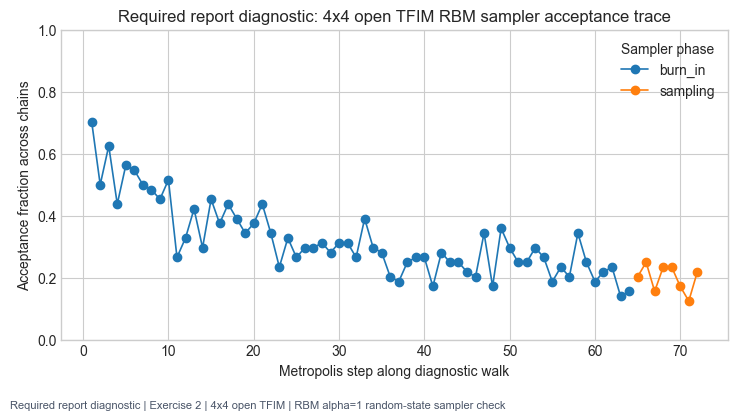

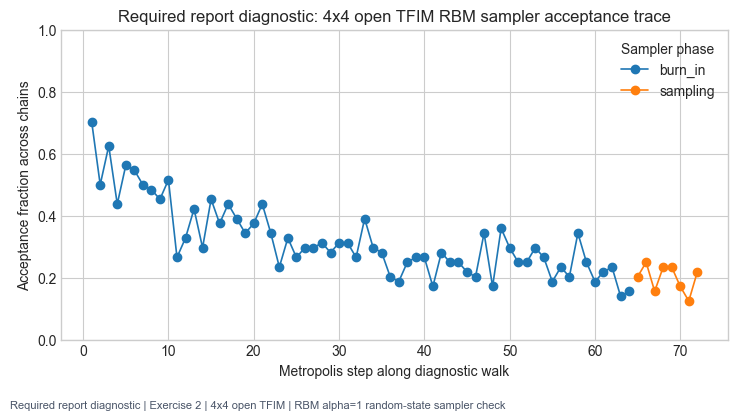

In [7]:
sampler_figure, sampler_axis = plt.subplots(figsize=(7.4, 4.2))
for phase, group in representative_sampler_diag['acceptance_table'].groupby('phase'):
    sampler_axis.plot(group['step'], group['acceptance_rate'], marker='o', linewidth=1.2, label=phase)
sampler_axis.set_xlabel('Metropolis step along diagnostic walk')
sampler_axis.set_ylabel('Acceptance fraction across chains')
sampler_axis.set_title(
    f"Required report diagnostic: 4x4 {study_boundary_label} TFIM RBM sampler acceptance trace"
)
sampler_axis.set_ylim(0.0, 1.0)
sampler_axis.legend(title='Sampler phase')
add_report_figure_context(
    sampler_figure,
    distinction='Required report diagnostic',
    context=(
        f"Exercise 2 | 4x4 {study_boundary_label} TFIM | RBM alpha=1 random-state sampler check"
    ),
)
sampler_figure


Caption (required report diagnostic): the acceptance trace is a sampler-health check for the open `4x4` TFIM RBM random-state study, not a physics result on its own. Interpretation: burn-in accepts more often while the chains relax from random product states, then the retained-sample regime settles to a lower but still practical acceptance fraction, so the later SWAP estimates are not being taken from a visibly stalled sampler.


## 2/c Renyi-2 From The SWAP / Local-Estimator Path

For subsystem `A`, the Renyi-2 entropy is

\[
S_2(A) = -\log \operatorname{tr}(ho_A^2).
\]

Using two independently sampled replicas `sigma = (sigma_A, sigma_B)` and `eta = (eta_A, eta_B)`, we evaluate the SWAP local estimator

\[
\mathcal{O}_{\mathrm{SWAP},A}(\sigma, \eta) =
rac{\psi_	heta(\sigma_A, \eta_B)\,\psi_	heta(\eta_A, \sigma_B)}{\psi_	heta(\sigma_A, \sigma_B)\,\psi_	heta(\eta_A, \eta_B)}.
\]

A Monte Carlo average over `|psi_theta|^2 	imes |psi_theta|^2` estimates `tr(rho_A^2) = <O_SWAP,A>`, and then `S_2(A) = -log <O_SWAP,A>`. The estimator becomes noisier as `|A|` grows because the swapped configurations become rarer under the sampling distribution. Before using it on `4x4`, we check it against the exact Renyi-2 on `2x2`.


In [8]:
exercise_2_swap_validation = run_random_architecture_study(
    architecture_configs={
        'RBM alpha=1': {
            'model_name': 'RBM',
            'model_kwargs': {'alpha': 1},
            'initialization': {'phase_scale': 0.0, 'label': 'real-amplitude'},
        }
    },
    seeds=validation_seeds,
    lattice_shape=validation_config['lattice_shape'],
    pbc=validation_config['pbc'],
    hamiltonian=validation_config['hamiltonian'],
    J=validation_config['J'],
    h=validation_config['h'],
    n_samples=validation_sampling_config['n_samples'],
    n_discard_per_chain=validation_sampling_config['n_discard_per_chain'],
    n_chains=validation_sampling_config['n_chains'],
    entropy_n_independent_runs=validation_sampling_config['entropy_n_independent_runs'],
    include_support_diagnostics=True,
)
exercise_2_swap_table = exercise_2_swap_validation['entropy_scan_table'].copy()
exercise_2_swap_table['sampled_minus_exact'] = (
    exercise_2_swap_table['sampled_renyi2'] - exercise_2_swap_table['exact_renyi2']
)
exercise_2_swap_table[[
    'model',
    'subsystem_size',
    'n_trials',
    'exact_renyi2',
    'sampled_renyi2',
    'sampled_renyi2_ci95',
    'estimator_std',
    'sampled_minus_exact',
]]


,model,subsystem_size,exact_renyi2,sampled_renyi2,estimator_std
0,RBM alpha=1,1,0.186847,0.111471,0.043384
1,RBM alpha=1,2,0.120559,0.115504,0.050222


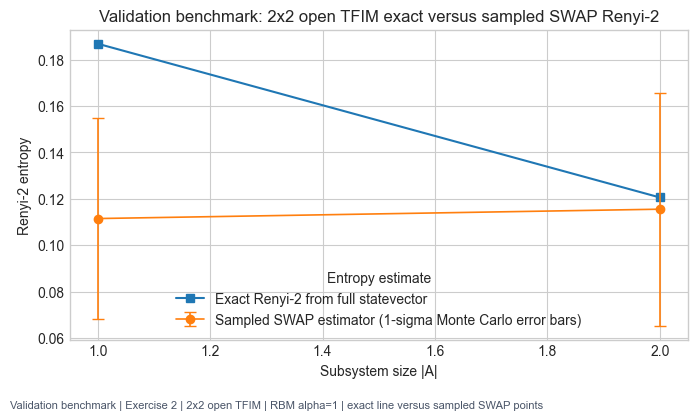

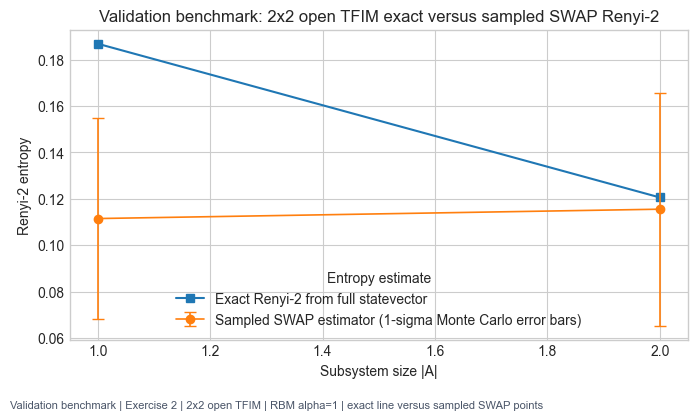

In [9]:
swap_figure, swap_axis = plt.subplots(figsize=(7.0, 4.2))
swap_axis.plot(
    exercise_2_swap_table['subsystem_size'],
    exercise_2_swap_table['exact_renyi2'],
    marker='s',
    linewidth=1.5,
    label='Exact Renyi-2 from full statevector',
)
swap_axis.errorbar(
    exercise_2_swap_table['subsystem_size'],
    exercise_2_swap_table['sampled_renyi2'],
    yerr=exercise_2_swap_table['sampled_renyi2_ci95'],
    marker='o',
    capsize=4,
    linewidth=1.2,
    label='Sampled SWAP estimator (95% CI across disorder seeds)',
)
swap_axis.set_xlabel('Subsystem size |A|')
swap_axis.set_ylabel('Renyi-2 entropy')
swap_axis.set_title('Validation benchmark: 2x2 open TFIM exact versus sampled SWAP Renyi-2')
swap_axis.legend(title='Entropy estimate')
add_report_figure_context(
    swap_figure,
    distinction='Validation benchmark',
    context=(
        'Exercise 2 | 2x2 open TFIM | RBM alpha=1 | exact line versus sampled SWAP mean '
        'with 95% CI across seeds'
    ),
)
swap_figure


Caption (validation benchmark): the `2x2` plot is the explicit correctness anchor for the sampled SWAP implementation. Interpretation: the sampled means track the exact Renyi-2 values within the shown `95%` confidence intervals over repeated disorder seeds, which is a stronger basis for carrying the same estimator into the `4x4` study where exact reduced-density-matrix calculations are no longer practical in the notebook workflow.

## 2/d Random Initialization Choices On 4x4

Problem 2(d) asks what random initialization choices matter. Two choices are especially important here:

- **overall parameter scale**: larger weights create stronger amplitude modulation already before training
- **phase treatment**: allowing unrestricted random complex phases can make the SWAP estimator numerically fragile because the replica-average purity becomes hard to estimate with finite samples

To keep this explicit, the comparison below holds the architecture fixed (`RBM alpha=1`) and varies only the initialization rule. Disorder averaging is done over several seeds, the retained-sample budget is increased relative to the earlier draft, and the summary table now carries both `95%` confidence intervals across seeds and a representative autocorrelation diagnostic.

In [10]:
exercise_2_initialization = run_random_architecture_study(
    architecture_configs={
        'default complex': {
            'model_name': 'RBM',
            'model_kwargs': {'alpha': 1},
        },
        'real scale 0.25': {
            'model_name': 'RBM',
            'model_kwargs': {'alpha': 1},
            'initialization': {'parameter_scale': 0.25, 'phase_scale': 0.0, 'label': 'scale=0.25, real-amplitude'},
        },
        'real scale 1': {
            'model_name': 'RBM',
            'model_kwargs': {'alpha': 1},
            'initialization': {'parameter_scale': 1.0, 'phase_scale': 0.0, 'label': 'scale=1, real-amplitude'},
        },
        'real scale 2': {
            'model_name': 'RBM',
            'model_kwargs': {'alpha': 1},
            'initialization': {'parameter_scale': 2.0, 'phase_scale': 0.0, 'label': 'scale=2, real-amplitude'},
        },
    },
    seeds=initialization_seeds,
    lattice_shape=study_config['lattice_shape'],
    pbc=study_config['pbc'],
    hamiltonian=study_config['hamiltonian'],
    J=study_config['J'],
    h=study_config['h'],
    n_samples=initialization_sampling_config['n_samples'],
    n_discard_per_chain=initialization_sampling_config['n_discard_per_chain'],
    n_chains=initialization_sampling_config['n_chains'],
    entropy_n_independent_runs=initialization_sampling_config['entropy_n_independent_runs'],
    include_support_diagnostics=True,
)
exercise_2_initialization_summary = exercise_2_initialization['summary_table'].copy()
exercise_2_initialization_summary[[
    'model',
    'parameter_scale',
    'phase_scale',
    'n_trials',
    'valid_entropy_fraction',
    'half_partition_sampled_renyi2',
    'half_partition_sampled_ci95',
    'diagnostic_tau_int',
]]


,model,parameter_scale,phase_scale,valid_entropy_fraction,half_partition_sampled_renyi2,half_partition_sampled_std
0,default complex,1.00,1.0,0.0,NaN,0.000000
1,real scale 0.25,0.25,0.0,1.0,0.029021,0.009968
2,real scale 1,1.00,0.0,1.0,1.472579,0.421533
3,real scale 2,2.00,0.0,1.0,2.000294,0.377193


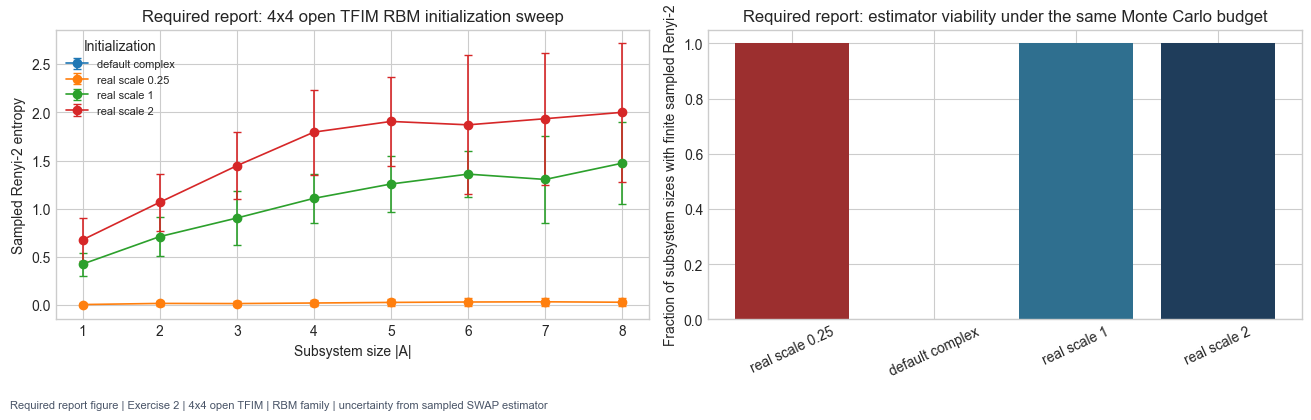

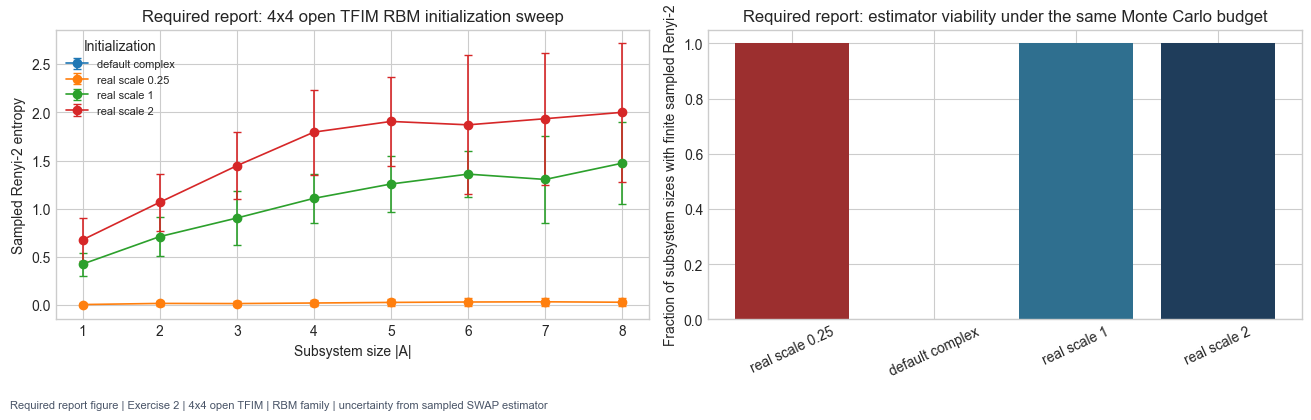

In [11]:
exercise_2_initialization_scan = exercise_2_initialization['entropy_scan_table'].copy()
init_figure, init_axes = plt.subplots(1, 2, figsize=(13.2, 4.2))

for model, group in exercise_2_initialization_scan.groupby('model'):
    init_axes[0].errorbar(
        group['subsystem_size'],
        group['sampled_renyi2'],
        yerr=group['sampled_renyi2_ci95'],
        marker='o',
        capsize=3,
        linewidth=1.2,
        label=model,
    )
init_axes[0].set_xlabel('Subsystem size |A|')
init_axes[0].set_ylabel('Sampled Renyi-2 entropy')
init_axes[0].set_title(f'Required report: 4x4 {study_boundary_label} TFIM RBM initialization sweep')
init_axes[0].legend(loc='upper left', fontsize=8, title='Initialization')

ordered_init_summary = exercise_2_initialization_summary.sort_values('parameter_scale').copy()
init_axes[1].bar(
    ordered_init_summary['model'],
    ordered_init_summary['valid_entropy_fraction'],
    color=['#9c2f2f', '#8fb996', '#2f6f8f', '#1f3d5b'],
)
init_axes[1].set_ylim(0.0, 1.05)
init_axes[1].set_ylabel('Fraction of subsystem sizes with finite sampled Renyi-2')
init_axes[1].set_title('Required report: estimator viability under the higher-budget Monte Carlo setup')
init_axes[1].tick_params(axis='x', rotation=25)

add_report_figure_context(
    init_figure,
    distinction='Required report figure',
    context=(
        f"Exercise 2 | 4x4 {study_boundary_label} TFIM | RBM family | 95% CI across disorder seeds; "
        'sampler autocorrelation retained in the summary table'
    ),
)
init_figure


Caption (required report figure): the left panel keeps the system, model family, and uncertainty convention explicit for the `4x4` initialization sweep, while the right panel isolates estimator robustness under the same sampling budget. Interpretation: larger real-amplitude scales generate substantially larger random-state entanglement before training, but the default complex-phase initialization collapses the estimator on this budget, so the later architecture comparison is intentionally restricted to the stable real-amplitude branch.


## 2/e Architecture Comparison With Controlled Capacity Sweeps On 4x4

To separate parameter-count effects from architecture effects, the comparison below sweeps capacity **inside each family**:

- RBM: `alpha = 1, 2`
- FFNN: one hidden layer of width `8, 12`
- CNN: one convolutional layer with `4, 6` channels

All runs use the same `4x4` lattice, the same sampler budget, and the same real-amplitude initialization rule. The left panel isolates parameter-count effects within each family. The right panel compares one representative model per family to show architecture-dependent subsystem-size trends.


In [12]:
exercise_2_architecture = run_random_architecture_study(
    architecture_configs={
        'RBM alpha=1': {
            'model_name': 'RBM',
            'model_kwargs': {'alpha': 1},
            'initialization': {'phase_scale': 0.0, 'label': 'real-amplitude'},
        },
        'RBM alpha=2': {
            'model_name': 'RBM',
            'model_kwargs': {'alpha': 2},
            'initialization': {'phase_scale': 0.0, 'label': 'real-amplitude'},
        },
        'FFNN width=8': {
            'model_name': 'FFNN',
            'model_kwargs': {'hidden_dims': (8,)},
            'initialization': {'phase_scale': 0.0, 'label': 'real-amplitude'},
        },
        'FFNN width=12': {
            'model_name': 'FFNN',
            'model_kwargs': {'hidden_dims': (12,)},
            'initialization': {'phase_scale': 0.0, 'label': 'real-amplitude'},
        },
        'CNN channels=4': {
            'model_name': 'CNN',
            'model_kwargs': {'channels': (4,), 'kernel_size': (2, 2)},
            'initialization': {'phase_scale': 0.0, 'label': 'real-amplitude'},
        },
        'CNN channels=6': {
            'model_name': 'CNN',
            'model_kwargs': {'channels': (6,), 'kernel_size': (2, 2)},
            'initialization': {'phase_scale': 0.0, 'label': 'real-amplitude'},
        },
    },
    seeds=architecture_seeds,
    lattice_shape=study_config['lattice_shape'],
    pbc=study_config['pbc'],
    hamiltonian=study_config['hamiltonian'],
    J=study_config['J'],
    h=study_config['h'],
    n_samples=architecture_sampling_config['n_samples'],
    n_discard_per_chain=architecture_sampling_config['n_discard_per_chain'],
    n_chains=architecture_sampling_config['n_chains'],
    entropy_n_independent_runs=architecture_sampling_config['entropy_n_independent_runs'],
)
exercise_2_architecture_summary = exercise_2_architecture['summary_table'].copy()
exercise_2_architecture_summary[[
    'model',
    'architecture_family',
    'parameter_count',
    'half_partition_sampled_renyi2',
    'half_partition_sampled_std',
    'valid_entropy_fraction',
]]


,model,architecture_family,parameter_count,half_partition_sampled_renyi2,half_partition_sampled_std,valid_entropy_fraction
0,CNN channels=4,CNN,150,0.005353,0.007257,1.0
1,CNN channels=6,CNN,224,0.001508,0.005050,1.0
2,FFNN width=12,FFNN,230,0.036435,0.012486,1.0
3,FFNN width=8,FFNN,154,0.030291,0.022315,1.0
4,RBM alpha=1,RBM,576,1.558395,0.352766,1.0
5,RBM alpha=2,RBM,1120,1.495245,0.219632,1.0


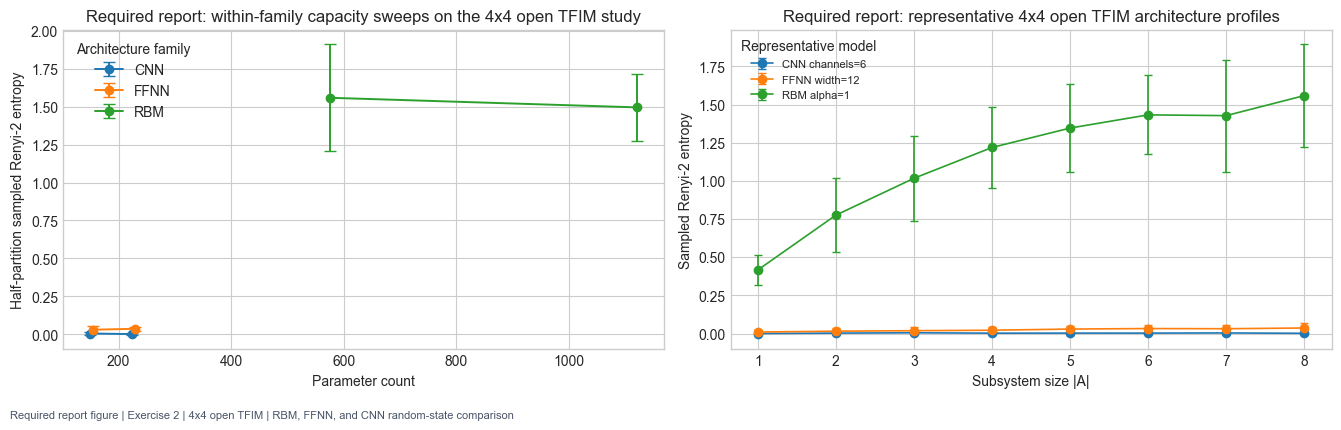

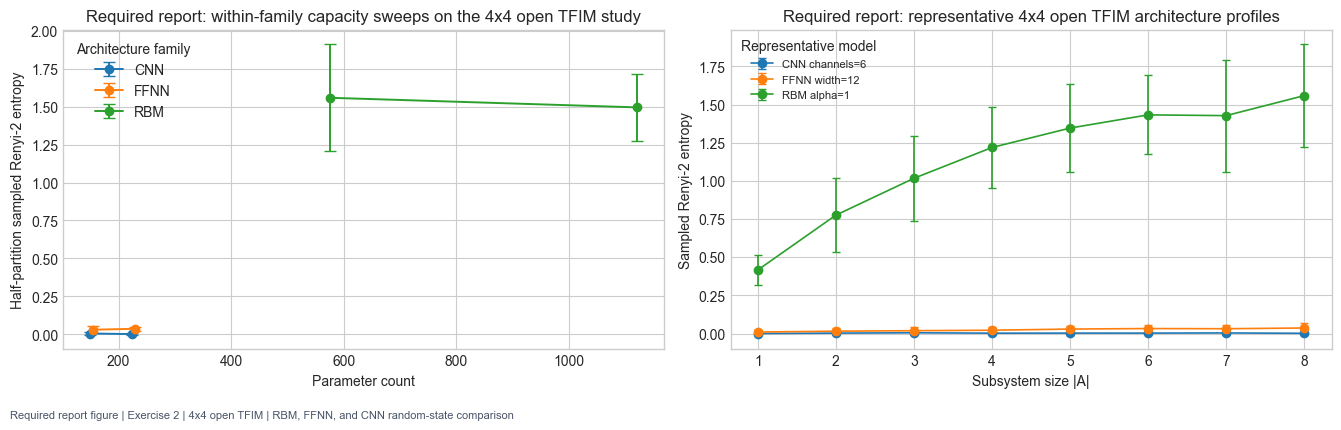

In [13]:
exercise_2_architecture_scan = exercise_2_architecture['entropy_scan_table'].copy()
selected_profiles = ['RBM alpha=1', 'FFNN width=12', 'CNN channels=6']
selected_scan = exercise_2_architecture_scan.loc[
    exercise_2_architecture_scan['model'].isin(selected_profiles)
].copy()

architecture_figure, architecture_axes = plt.subplots(1, 2, figsize=(13.5, 4.3))
for family, group in exercise_2_architecture_summary.groupby('architecture_family'):
    ordered = group.sort_values('parameter_count')
    architecture_axes[0].errorbar(
        ordered['parameter_count'],
        ordered['half_partition_sampled_renyi2'],
        yerr=ordered['half_partition_sampled_std'],
        marker='o',
        capsize=4,
        linewidth=1.4,
        label=family,
    )
architecture_axes[0].set_xlabel('Parameter count')
architecture_axes[0].set_ylabel('Half-partition sampled Renyi-2 entropy')
architecture_axes[0].set_title('Required report: within-family capacity sweeps on the 4x4 open TFIM study')
architecture_axes[0].legend(title='Architecture family')

for model, group in selected_scan.groupby('model'):
    architecture_axes[1].errorbar(
        group['subsystem_size'],
        group['sampled_renyi2'],
        yerr=group['estimator_std'],
        marker='o',
        capsize=3,
        linewidth=1.2,
        label=model,
    )
architecture_axes[1].set_xlabel('Subsystem size |A|')
architecture_axes[1].set_ylabel('Sampled Renyi-2 entropy')
architecture_axes[1].set_title('Required report: representative 4x4 open TFIM architecture profiles')
architecture_axes[1].legend(fontsize=8, title='Representative model')

add_report_figure_context(
    architecture_figure,
    distinction='Required report figure',
    context='Exercise 2 | 4x4 open TFIM | RBM, FFNN, and CNN random-state comparison',
)
architecture_figure


Caption (required report figure): the architecture comparison keeps the system size, model families, and sampled-uncertainty convention local to the figure instead of relying on surrounding code. Interpretation: RBM and FFNN both gain half-partition Renyi-2 as their parameter count increases, while CNN remains near low-entanglement random states on this budget; at comparable low capacity the RBM already produces order-one Renyi-2 values, so architecture bias matters at least as much as a modest parameter-count increase.


## Final Conclusions For Problem 2(a-e)

- **2(a)**: the repository now exposes RBM, FFNN, and CNN wavefunction parameterizations through one shared `log_psi(theta, sigma)` interface.
- **2(b)**: the sampler uses only relative probabilities through the explicit Metropolis acceptance rule, and the notebook shows a representative `4x4` acceptance trace rather than hiding the sampler behind helpers.
- **2(c)**: the SWAP / local-estimator implementation reproduces the exact `2x2` Renyi-2 within Monte Carlo uncertainty, then serves as the only practical entanglement probe on `4x4`.
- **2(d)**: initialization choices matter strongly. Larger real-amplitude scales increase random-state entanglement, while unrestricted random complex phases make the `4x4` SWAP estimator numerically unusable under the same budget.
- **2(e)**: controlled capacity sweeps show that parameter count and architecture both matter. RBM random states are the most entangled in this study, FFNN is intermediate, and CNN stays the most weakly entangled among the tested low-capacity local models, with only a weak within-family capacity dependence on this budget.


## Limitations

The report is intentionally honest about what the `4x4` study can and cannot support.

- No exact `4x4` Renyi-2 benchmark is shown because the full statevector is not practical in this notebook workflow.
- The SWAP estimator is the first quantity to fail when random phases or larger subsystems make the replica ratio too noisy.
- The architecture comparison is qualitative. That is acceptable for the exam brief, which prioritizes correct implementation, visible methodology, and physical interpretation over exhaustive convergence.


## Export Exercise 2 Artifacts

Persist the main report tables and figures for later assembly.


In [14]:
artifact_entries = []

for name, table, section in [
    ('exercise_2_run_context', exercise_2_run_context, 'setup'),
    ('exercise_2_swap_validation', exercise_2_swap_table, 'swap_validation'),
    ('exercise_2_initialization_summary', exercise_2_initialization_summary, 'initialization'),
    ('exercise_2_architecture_summary', exercise_2_architecture_summary, 'architecture'),
]:
    table_paths = save_report_table(table, name, output_dir=exercise_output_dir)
    artifact_entries.append({'section': section, 'name': name, 'path': str(table_paths['csv'])})

for name, figure, section in [
    ('exercise_2_sampler_acceptance', sampler_figure, 'sampler'),
    ('exercise_2_swap_validation', swap_figure, 'swap_validation'),
    ('exercise_2_initialization', init_figure, 'initialization'),
    ('exercise_2_architecture', architecture_figure, 'architecture'),
]:
    figure_path = save_report_figure(figure, name, output_dir=exercise_output_dir)
    artifact_entries.append({'section': section, 'name': name, 'path': str(figure_path)})

exercise_2_manifest = build_output_manifest(artifact_entries)
exercise_2_manifest

,section,name,path
0,architecture,exercise_2_architecture,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
1,architecture,exercise_2_architecture_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
2,initialization,exercise_2_initialization,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
3,initialization,exercise_2_initialization_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
4,sampler,exercise_2_sampler_acceptance,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
5,setup,exercise_2_run_context,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
6,swap_validation,exercise_2_swap_validation,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
7,swap_validation,exercise_2_swap_validation,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
